# Principal Component Analysis (PCA)

## 📚 Learning Objectives

By completing this notebook, you will:
- Implement PCA for dimensionality reduction
- Interpret explained variance and components
- Use PCA for visualization and preprocessing

## 🔗 Prerequisites

- ✅ Basic Python
- ✅ Basic NumPy/Pandas (when applicable)

---

---

# Principal Component Analysis (PCA)

## 📚 Prerequisites (What You Need First)

**BEFORE starting this notebook**, you should have completed:
- ✅ **Module 01: Linear Algebra** - Understand eigenvalues and eigenvectors
- ✅ **Module 03: Optimization** - Understand optimization concepts
- ✅ **Basic understanding**: What is dimensionality reduction?

**If you haven't completed these**, you might struggle with:
- Understanding PCA algorithm
- Understanding eigenvalue decomposition
- Applying PCA to data

---

## 🔗 Where This Notebook Fits

**This is the FIRST example of Module 04** - reducing dimensions!

**Why this example FIRST?**
- **Before** you can reduce dimensions, you need PCA
- **Before** you can understand other techniques, you need PCA foundation
- **Before** you can handle high-dimensional data, you need dimensionality reduction

**Builds on**: Module 01 (eigenvalues), Module 03 (optimization)

**Leads to**: Example 2: Curse of Dimensionality, Example 3: Feature Selection

---

## The Story: Understanding Before Using

Imagine you have a 1000-page book but only need the key points. **Before** you can summarize, you need to find the most important pages. **After** understanding PCA, you can reduce data dimensions while keeping the most important information!

Same with machine learning: **Before** handling high-dimensional data, we struggle with complexity. **After** understanding PCA, we can reduce dimensions while preserving information!

---

## Why This Concept Matters

### Why PCA Matters in ML

**WHY** is PCA essential?

1. **Dimensionality Reduction**:
   - **WHY**: High-dimensional data is hard to work with
   - **HOW**: PCA finds directions of maximum variance
   - **AFTER**: Simpler, more manageable data

2. **Data Compression**:
   - **WHY**: Reduce storage and computation
   - **HOW**: Keep only important components
   - **AFTER**: Faster training and inference

3. **Visualization**:
   - **WHY**: Can't visualize high-dimensional data
   - **HOW**: Project to 2D/3D using PCA
   - **AFTER**: Can visualize and understand data

**Common Student Questions:**
- **Q: What is PCA?**
  - Answer: PCA = Principal Component Analysis = finds directions of maximum variance
  - Problem: High-dimensional data (many features) is hard to work with
  - Solution: PCA finds new axes (principal components) that capture most information
  - Result: Reduced dimensions while keeping most information
- **Q: Why use PCA?**
  - Answer: Reduces dimensions → faster training, less storage, easier visualization
  - Problem: 1000 features → slow training, hard to visualize
  - Solution: PCA reduces to 10-50 components → much faster, can visualize
  - Trade-off: Some information lost, but usually minimal
- **Q: What is explained variance?**
  - Answer: Explained variance = how much information each component captures
  - Example: First component captures 40% variance, second captures 20% → together = 60%
  - Rule of thumb: Keep components that explain 80-95% of variance
  - More components = more information kept, but more dimensions
- **Q: How many components should I keep?**
  - Answer: Keep enough to explain 80-95% of variance
  - Too few: Lose important information
  - Too many: Don't reduce dimensions much
  - Use elbow method: Plot explained variance → find where curve flattens
  - Example: 10 components explain 90% → keep 10 (good balance)
- **Q: Does PCA lose information?**
  - Answer: Yes, but usually minimal if done correctly
  - PCA keeps directions of maximum variance → discards less important directions
  - If 95% variance explained → only 5% information lost
  - Trade-off: Small information loss for huge dimension reduction
  - In practice: Often improves model performance (removes noise)

## Learning Objectives
1. Understand PCA algorithm
2. Apply PCA to reduce dimensions
3. Understand explained variance
4. Visualize PCA results
5. Apply to real ML scenarios

---

## Step 1: Import necessary libraries


## 📥 Inputs & 📤 Outputs

**Inputs:** What we use in this notebook

- Libraries and concepts as introduced in this notebook; see prerequisites and code comments.

**Outputs:** What you'll see when you run the cells

- Printed results, figures, and summaries as shown when you run the cells.

---

In [1]:
import numpy as np
import matplotlib.pyplot as plt

print('✅ Libraries imported successfully!')

✅ Libraries imported successfully!


---

## Part 1: Setting the Scene

**BEFORE**: We have concepts but don't know how to implement them.

**AFTER**: We'll implement and understand how this works in ML!

## Step 2: Implementation

**BEFORE**: We understand the concept.

**AFTER**: We'll see HOW it's implemented!

In [2]:
# Example 1: PCA Implementation
# WHY: Reduce dimensions while keeping information
# HOW: Find eigenvectors of covariance matrix (Module 01!)

try:
    from sklearn.decomposition import PCA
    from sklearn.preprocessing import StandardScaler
    
    # Create CORRELATED sample data: 10 observed features driven by 3 latent factors.
    # (PCA can only compress correlated features — on independent features there is
    #  nothing to exploit and the explained variance stays low.)
    np.random.seed(42)
    latent = np.random.randn(100, 3)   # 3 hidden factors
    mixing = np.random.randn(3, 10)    # how the factors map to 10 features
    data = latent @ mixing + 0.3 * np.random.randn(100, 10)  # + measurement noise
    
    # Standardize data
    scaler = StandardScaler()
    data_scaled = scaler.fit_transform(data)
    
    # Apply PCA
    pca = PCA(n_components=3)
    data_reduced = pca.fit_transform(data_scaled)
    
    print("Example 1: PCA Implementation")
    print("=" * 60)
    print(f"Original data shape: {data.shape}")
    print(f"Reduced data shape: {data_reduced.shape}")
    print(f"\nExplained variance ratios: {pca.explained_variance_ratio_}")
    print(f"Total variance explained: {pca.explained_variance_ratio_.sum():.1%}")
    print(f"\n💡 WHY: Reduced from {data.shape[1]}D to {data_reduced.shape[1]}D")
    print(f"💡 HOW: Found directions of maximum variance (eigenvectors)")
    print(f"💡 AFTER: Preserved {pca.explained_variance_ratio_.sum():.1%} of information!")
except ImportError:
    print("Note: sklearn not available, but PCA uses eigenvalues from Module 01!")

Example 1: PCA Implementation
Original data shape: (100, 10)
Reduced data shape: (100, 3)

Explained variance ratios: [0.55971795 0.26498117 0.12875322]
Total variance explained: 95.3%

💡 WHY: Reduced from 10D to 3D
💡 HOW: Found directions of maximum variance (eigenvectors)
💡 AFTER: Preserved 95.3% of information!


---

## 📊 Visualization

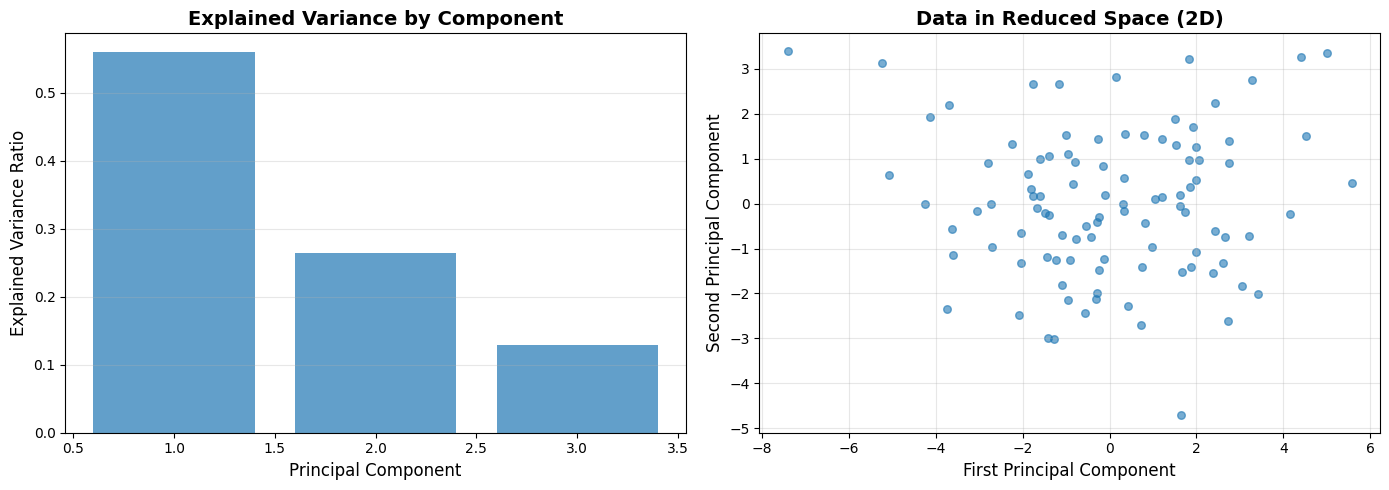


📊 Visualization:
  - Left: Variance explained by each component
  - Right: Data projected to 2D using first 2 components


In [3]:
# Visualize PCA results
try:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Plot 1: Explained variance
    axes[0].bar(range(1, len(pca.explained_variance_ratio_)+1), pca.explained_variance_ratio_, alpha=0.7)
    axes[0].set_xlabel('Principal Component', fontsize=12)
    axes[0].set_ylabel('Explained Variance Ratio', fontsize=12)
    axes[0].set_title('Explained Variance by Component', fontsize=14, fontweight='bold')
    axes[0].grid(True, alpha=0.3, axis='y')
    
    # Plot 2: Data in reduced space
    axes[1].scatter(data_reduced[:, 0], data_reduced[:, 1], alpha=0.6, s=30)
    axes[1].set_xlabel('First Principal Component', fontsize=12)
    axes[1].set_ylabel('Second Principal Component', fontsize=12)
    axes[1].set_title('Data in Reduced Space (2D)', fontsize=14, fontweight='bold')
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    print("\n📊 Visualization:")
    print("  - Left: Variance explained by each component")
    print("  - Right: Data projected to 2D using first 2 components")
except:
    print("Visualization requires sklearn")

---

## Part 3: AFTER - Results and Implications

### What This Enables

**AFTER** understanding PCA:

1. **Dimensionality Reduction**: Can reduce data dimensions
2. **Data Compression**: Can compress data efficiently
3. **Visualization**: Can visualize high-dimensional data
4. **Next Steps**: Learn curse of dimensionality (Example 2) and feature selection (Example 3)

---

## 🎯 Summary: What We Learned

**BEFORE this notebook**: We didn't understand this concept.

**AFTER this notebook**: We understand WHY, HOW, and AFTER!

---

## ✅ Example Complete!

## 📚 References

1. Pearson, K. (1901). *On Lines and Planes of Closest Fit to Systems of Points in Space*. Philosophical Magazine, 2(11), 559–572.
2. Hotelling, H. (1933). *Analysis of a Complex of Statistical Variables into Principal Components*. Journal of Educational Psychology, 24, 417–441.
3. Jolliffe, I. T., & Cadima, J. (2016). *Principal Component Analysis: A Review and Recent Developments*. Philosophical Transactions of the Royal Society A, 374(2065). <https://doi.org/10.1098/rsta.2015.0202>